# Part 3: Dependence and Copula Selection

## Research Question

Are defaults largely independent, driven by a single systematic factor, or driven by regional systematic factors?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys

sys.path.append("../src")

from dependence import *
from marginals import *

SEED = 42
np.random.seed(SEED)

FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# LOAD CLEAN DATA
# --------------------------------------------------

df = pd.read_csv(
    "../outputs/cleaned/loan_tape_clean.csv"
)

date_cols = [
    "origination_date",
    "default_date",
    "analysis_end_date"
]

for col in date_cols:

    df[col] = pd.to_datetime(
        df[col],
        errors="coerce"
    )

print(df.shape)

df.head()

(277867, 39)


,origination_date,loan_id,region,fico_score,term,maturity_date,default_date,prepayment_date,obs_end_date,issue_amount,...,prepayment_event,event_date,event_type,censoring_date,analysis_end_date,loan_age_days,loan_age_months,EAD_at_default,balance_at_prepayment,balance_at_obs_end
0,1993-03-01,ID_00000002,Northeast,811.0,60,1998-03-01,NaT,1996-09-15,2026-06-16,5270.56,...,1,1996-09-15,prepayment,1998-03-01,1996-09-15,1294,42.513347,NaN,5270.56,0.0
1,1993-03-01,ID_00000059,Northeast,696.0,60,1998-03-01,1993-11-01,NaN,2026-06-16,8058.00,...,0,1993-11-01,default,1998-03-01,1993-11-01,245,8.049281,6983.600000,NaN,0.0
2,1993-03-01,ID_00000064,Northeast,840.0,60,1998-03-01,1998-02-01,NaN,2026-06-16,6960.84,...,0,1998-02-01,default,1998-03-01,1998-02-01,1798,59.071869,6960.840000,NaN,0.0
3,1993-03-01,ID_00000086,Northeast,733.0,12,1994-03-01,1993-08-01,NaN,2026-06-16,3071.63,...,0,1993-08-01,default,1994-03-01,1993-08-01,153,5.026694,1791.784167,NaN,0.0
4,1993-03-01,ID_00000088,Northeast,825.0,60,1998-03-01,1997-06-01,NaN,2026-06-16,8197.42,...,0,1997-06-01,default,1998-03-01,1997-06-01,1553,51.022587,8197.420000,NaN,0.0


### 1. Create parameter lookup

In [2]:
# ============================================================
# FICO-specific marginal parameters (Weibull)
# ============================================================

fico_params = {

    "<580": {
        "shape": 1.195284,
        "scale": 157.805497,
        "default_rate": 0.1461
    },

    "580-669": {
        "shape": 1.386856,
        "scale": 272.232413,
        "default_rate": 0.0576
    },

    "670-739": {
        "shape": 1.432946,
        "scale": 260.444336,
        "default_rate": 0.0567
    },

    "740-799": {
        "shape": 1.394607,
        "scale": 272.427402,
        "default_rate": 0.0572
    },

    "800+": {
        "shape": 1.443613,
        "scale": 256.310957,
        "default_rate": 0.0569
    }
}

fico_table = pd.DataFrame(
    fico_params
).T

display(fico_table)


,shape,scale,default_rate
<580,1.195284,157.805497,0.1461
580-669,1.386856,272.232413,0.0576
670-739,1.432946,260.444336,0.0567
740-799,1.394607,272.427402,0.0572
800+,1.443613,256.310957,0.0569


### 2. Build Annual FICO Default-Rate Panel


Why?

We cannot estimate obligor-to-obligor dependence directly because each loan has only one observed outcome.

Therefore we must infer latent dependence through common default patterns across segments.

fico_band,580-669,670-739,740-799,800+,<580
year,,,,,
1993,0.000181,0.000175,0.000235,0.000239,0.000496
1994,0.000430,0.000380,0.000637,0.000439,0.001518
1995,0.000724,0.000759,0.001005,0.000519,0.002547
1996,0.000973,0.001372,0.001374,0.000878,0.003180
1997,0.001199,0.001547,0.001206,0.001197,0.003677


fico_band,580-669,670-739,740-799,800+,<580
fico_band,,,,,
580-669,1.000,0.264,0.396,0.347,0.410
670-739,0.264,1.000,0.458,0.288,0.329
740-799,0.396,0.458,1.000,0.359,0.530
800+,0.347,0.288,0.359,1.000,0.405
<580,0.410,0.329,0.530,0.405,1.000


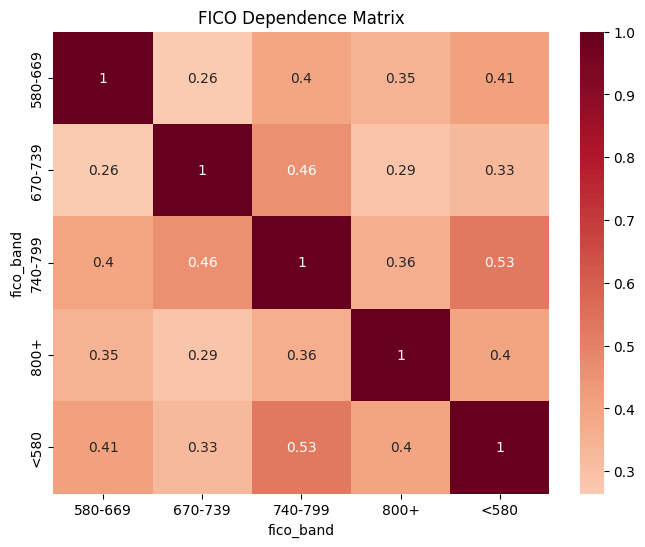

Average tau = 0.3786
Implied rho = 0.5602


95% CI: [0.14702843 0.5863551 ]


In [3]:
# ============================================================
# FICO bands
# ============================================================

def create_fico_band(x):

    if pd.isna(x):
        return np.nan

    if x < 580:
        return "<580"

    elif x < 670:
        return "580-669"

    elif x < 740:
        return "670-739"

    elif x < 800:
        return "740-799"

    else:
        return "800+"

df["fico_band"] = (
    df["fico_score"]
    .apply(create_fico_band)
)


# ============================================================
# Annual default-rate panel by FICO band
# ============================================================

annual_rates = (
    build_fico_default_panel(df)
)

display(
    annual_rates.head()
)


# ============================================================
# Kendall tau dependence matrix
# ============================================================

tau_matrix = compute_tau_matrix(
    annual_rates
)

display(
    tau_matrix.round(3)
)

plt.figure(figsize=(8,6))

sns.heatmap(
    tau_matrix,
    annot=True,
    cmap="RdBu_r",
    center=0
)

plt.title(
    "FICO Dependence Matrix"
)
plt.savefig(
    "../outputs/figures/fico_dependence_matrix.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# ============================================================
# Average tau -> implied Gaussian-scale correlation rho
# ============================================================

avg_tau = average_tau(
    tau_matrix
)

rho = tau_to_rho(
    avg_tau
)

print(f"Average tau = {avg_tau:.4f}")
print(f"Implied rho = {rho:.4f}")


# ============================================================
# Bootstrap CI on average tau
# ============================================================

boot = bootstrap_tau(
    annual_rates,
    n_boot=1000,
    seed=SEED
)

tau_ci = np.percentile(
    boot,
    [2.5, 97.5]
)

print("95% CI:", tau_ci)


In [4]:
import itertools

region_fico_rates = build_region_fico_default_panel(df)

region_fico_tau = compute_tau_matrix(region_fico_rates)

def parse_cell(cell):
    region, fico = cell.split(" | ")
    return region, fico

within_segment = []   # same FICO band, different region
cross_segment = []    # different FICO band

for c1, c2 in itertools.combinations(region_fico_tau.columns, 2):
    tau_val = region_fico_tau.loc[c1, c2]
    if pd.isna(tau_val):
        continue

    r1, f1 = parse_cell(c1)
    r2, f2 = parse_cell(c2)

    if f1 == f2:
        within_segment.append(tau_val)
    else:
        cross_segment.append(tau_val)

within_segment = np.array(within_segment)
cross_segment = np.array(cross_segment)

print(f"Within-FICO-segment tau (n={len(within_segment)}): {within_segment.mean():.4f}")
print(f"Cross-FICO-segment tau  (n={len(cross_segment)}): {cross_segment.mean():.4f}")
print(f"Difference (within - cross): {within_segment.mean() - cross_segment.mean():.4f}")


# Permutation test: is the within/cross difference real, or noise?
def permutation_test_segment_effect(within_vals, cross_vals, n_perm=5000, seed=42):
    rng = np.random.default_rng(seed)
    observed_diff = within_vals.mean() - cross_vals.mean()

    combined = np.concatenate([within_vals, cross_vals])
    n_within = len(within_vals)

    perm_diffs = np.empty(n_perm)
    for i in range(n_perm):
        rng.shuffle(combined)
        perm_diffs[i] = combined[:n_within].mean() - combined[n_within:].mean()

    p_value = (np.abs(perm_diffs) >= np.abs(observed_diff)).mean()
    return observed_diff, p_value

obs_diff, p_value = permutation_test_segment_effect(within_segment, cross_segment)

print(f"\nObserved within-vs-cross difference: {obs_diff:.4f}")
print(f"Permutation p-value: {p_value:.4f}")

Within-FICO-segment tau (n=36): 0.2712
Cross-FICO-segment tau  (n=240): 0.2547
Difference (within - cross): 0.0165

Observed within-vs-cross difference: 0.0165
Permutation p-value: 0.4030


In [5]:
from scipy.optimize import minimize_scalar

def empirical_tail_dependence(x, y, quantile=0.75):
    """
    Rough empirical upper-tail dependence coefficient. With only ~30
    annual observations this is high-variance -- intended to anchor
    nu, not to replace a full nonparametric estimator.
    """
    x_rank = pd.Series(x).rank(pct=True)
    y_rank = pd.Series(y).rank(pct=True)

    exceed_x = x_rank > quantile
    n_exceed_x = exceed_x.sum()
    if n_exceed_x == 0:
        return np.nan

    joint_exceed = (exceed_x & (y_rank > quantile)).sum()
    return joint_exceed / n_exceed_x


pairs = list(itertools.combinations(annual_rates.columns, 2))

emp_tail_deps = []
for c1, c2 in pairs:
    paired = annual_rates[[c1, c2]].dropna()
    if len(paired) < 10:
        continue
    emp_tail_deps.append(empirical_tail_dependence(paired[c1], paired[c2], quantile=0.75))

empirical_lambda = np.nanmean(emp_tail_deps)

print(f"Empirical average upper-tail dependence (q=0.75): {empirical_lambda:.4f}")
print(f"(based on {len(emp_tail_deps)} FICO-band pairs, {len(annual_rates)} years each)")


# Fit nu to match this empirical target, given the already-computed rho
def tail_dep_gap(nu, rho, target_lambda):
    return (t_tail_dependence(rho, nu) - target_lambda) ** 2

fit_result = minimize_scalar(
    tail_dep_gap,
    bounds=(2.05, 30),
    method="bounded",
    args=(rho, empirical_lambda)
)

nu_fitted = fit_result.x
implied_lambda_fitted = t_tail_dependence(rho, nu_fitted)

print(f"\nFitted nu (matching empirical tail dependence): {nu_fitted:.2f}")
print(f"Implied tail dependence at fitted nu:            {implied_lambda_fitted:.4f}")
print(f"Empirical target:                                {empirical_lambda:.4f}")


# Bootstrap CI on the fitted nu — years resampled, not pairs
def bootstrap_nu(annual_rates, rho, n_boot=500, seed=42, quantile=0.75):
    rng = np.random.default_rng(seed)
    years = annual_rates.index.to_numpy()
    pairs = list(itertools.combinations(annual_rates.columns, 2))
    nu_boot = []

    for _ in range(n_boot):
        sample_years = rng.choice(years, size=len(years), replace=True)
        sample = annual_rates.loc[sample_years]

        lambdas = [
            empirical_tail_dependence(sample[[c1, c2]].dropna()[c1],
                                       sample[[c1, c2]].dropna()[c2], quantile)
            for c1, c2 in pairs
            if len(sample[[c1, c2]].dropna()) >= 10
        ]
        if not lambdas:
            continue

        target = np.nanmean(lambdas)
        res = minimize_scalar(tail_dep_gap, bounds=(2.05, 30), method="bounded",
                               args=(rho, target))
        nu_boot.append(res.x)

    return np.array(nu_boot)

nu_boot = bootstrap_nu(annual_rates, rho, n_boot=500, seed=SEED)
print(f"\nFitted nu 95% CI: {np.percentile(nu_boot, [2.5, 97.5])}")

Empirical average upper-tail dependence (q=0.75): 0.3667
(based on 10 FICO-band pairs, 34 years each)

Fitted nu (matching empirical tail dependence): 2.74
Implied tail dependence at fitted nu:            0.3667
Empirical target:                                0.3667



Fitted nu 95% CI: [2.05000574 4.78571766]


In [6]:
# ============================================================
# Illustrative sensitivity: how tail dependence varies with nu
# (One-Factor only — Hierarchical is not distinguishable by this
#  formula and was rejected on evidence, see permutation test above)
# ============================================================

nu_values = [2, 3, 4, 6, 10]

rows = [
    {
        "Structure": "Independence",
        "Marginals": "FICO Weibull",
        "nu": np.nan,
        "Tail Dependence": 0.0,
        "Economic Interpretation": "No shared risk"
    },
    {
        "Structure": "One-Factor Gaussian",
        "Marginals": "FICO Weibull",
        "nu": np.nan,
        "Tail Dependence": 0.0,
        "Economic Interpretation": "Common macro factor, no stress clustering"
    }
]

for nu in nu_values:
    rows.append({
        "Structure": f"One-Factor Student-t (ν={nu})",
        "Marginals": "FICO Weibull",
        "nu": nu,
        "Tail Dependence": t_tail_dependence(rho=rho, nu=nu),
        "Economic Interpretation": "Common macro factor with stress clustering"
    })

model_comparison = pd.DataFrame(rows)
display(model_comparison.round(4))


# ============================================================
# Final selected dependence structure — evidence-based
# (see: within/cross-segment permutation test, empirical
#  tail-dependence fit for nu, both run above)
# ============================================================

selected_model = {
    "Dependence": "One-Factor Student-t",
    "rho": rho,
    "nu": round(nu_fitted, 2),
    "within_vs_cross_segment_p_value": round(p_value, 4),
    "empirical_tail_dependence": round(empirical_lambda, 4)
}

selected_model

,Structure,Marginals,nu,Tail Dependence,Economic Interpretation
0,Independence,FICO Weibull,NaN,0.0000,No shared risk
1,One-Factor Gaussian,FICO Weibull,NaN,0.0000,"Common macro factor, no stress clustering"
2,One-Factor Student-t (ν=2),FICO Weibull,2.0,0.4256,Common macro factor with stress clustering
3,One-Factor Student-t (ν=3),FICO Weibull,3.0,0.3482,Common macro factor with stress clustering
4,One-Factor Student-t (ν=4),FICO Weibull,4.0,0.2885,Common macro factor with stress clustering
5,One-Factor Student-t (ν=6),FICO Weibull,6.0,0.2029,Common macro factor with stress clustering
6,One-Factor Student-t (ν=10),FICO Weibull,10.0,0.1060,Common macro factor with stress clustering


{'Dependence': 'One-Factor Student-t',
 'rho': np.float64(0.5602355886797563),
 'nu': np.float64(2.74),
 'within_vs_cross_segment_p_value': np.float64(0.403),
 'empirical_tail_dependence': np.float64(0.3667)}

## Part 4 Diversification Analysis

In [7]:
regional_rates = (
    build_regional_default_panel(df)
)

regional_tau = (
    compute_tau_matrix(
        regional_rates
    )
)

display(
    regional_tau.round(3)
)

region,Northeast,Pacific,Southeast,Southwest
region,,,,
Northeast,1.000,0.408,0.267,0.356
Pacific,0.408,1.000,0.313,0.520
Southeast,0.267,0.313,1.000,0.431
Southwest,0.356,0.520,0.431,1.000


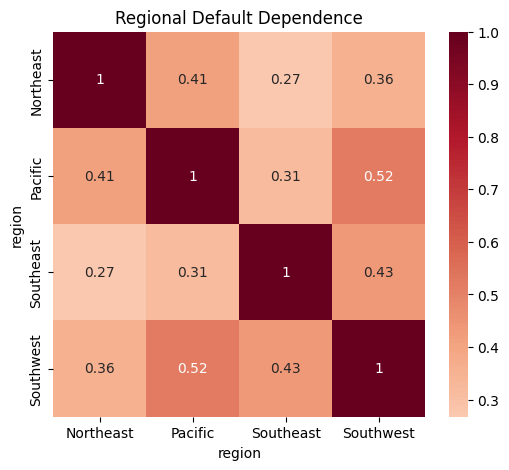

In [8]:
plt.figure(figsize=(6,5))

sns.heatmap(
    regional_tau,
    annot=True,
    cmap="RdBu_r",
    center=0
)

plt.title(
    "Regional Default Dependence"
)
plt.savefig("../outputs/figures/regional_default_dependence.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [9]:
# regional default table
regional_summary = (
    df.groupby("region")
      .agg(
          loans=("loan_id","count"),
          defaults=("default_event","sum")
      )
)

regional_summary["default_rate"] = (
    regional_summary["defaults"]
    /
    regional_summary["loans"]
)

display(
    regional_summary
)

,loans,defaults,default_rate
region,,,
Northeast,62494,11334,0.181361
Pacific,71073,6284,0.088416
Southeast,72496,4626,0.063810
Southwest,71804,6232,0.086792


Although default rates differ substantially across regions,
regional default rates remain positively correlated through
time. This suggests the presence of a shared systematic
factor, implying that regional diversification does not
fully eliminate portfolio tail risk.